In [1]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np
import os

In [3]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models

In [5]:
print(tf.__version__)

2.20.0


In [7]:
IMG_SIZE = 224
BATCH_SIZE = 32
EPOCHS = 2

In [9]:
train_dir = r"C:\Users\sai\Downloads\Plant_Disease_Dataset (1)\New Plant Diseases Dataset(Augmented)\train"
valid_dir = r"C:\Users\sai\Downloads\Plant_Disease_Dataset (1)\New Plant Diseases Dataset(Augmented)\valid"
test_dir  = r"C:\Users\sai\Downloads\Plant_Disease_Dataset (1)\New Plant Diseases Dataset(Augmented)\test"

In [71]:
diseases = os.listdir(train_dir)
print(diseases)

['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy', 'Blueberry___healthy', 'Cherry_(including_sour)___healthy', 'Cherry_(including_sour)___Powdery_mildew', 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot', 'Corn_(maize)___Common_rust_', 'Corn_(maize)___healthy']


In [73]:
plants = []
NumberOfDiseases = 0
for plant in diseases:
    if plant.split('___')[0] not in plants:
        plants.append(plant.split('___')[0])
    if plant.split('___')[1] != 'healthy':
        NumberOfDiseases += 1

In [75]:
# unique plants in the dataset
print(f"Unique Plants are: \n{plants}")

Unique Plants are: 
['Apple', 'Blueberry', 'Cherry_(including_sour)', 'Corn_(maize)']


In [79]:
# Number of images for each disease
import pandas as pd
nums = {}
for disease in diseases:
    nums[disease] = len(os.listdir(train_dir + '/' + disease))
    
# converting the nums dictionary to pandas dataframe passing index as plant name and number of images as column

img_per_class = pd.DataFrame(nums.values(), index=nums.keys(), columns=["no. of images"])
img_per_class

,no. of images
Apple___Apple_scab,2016
Apple___Black_rot,1987
Apple___Cedar_apple_rust,1760
Apple___healthy,2008
Blueberry___healthy,1816
Cherry_(including_sour)___healthy,1826
Cherry_(including_sour)___Powdery_mildew,1683
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot,1642
Corn_(maize)___Common_rust_,1907
Corn_(maize)___healthy,1859


Text(0.5, 1.0, 'Images per each class of plant disease')

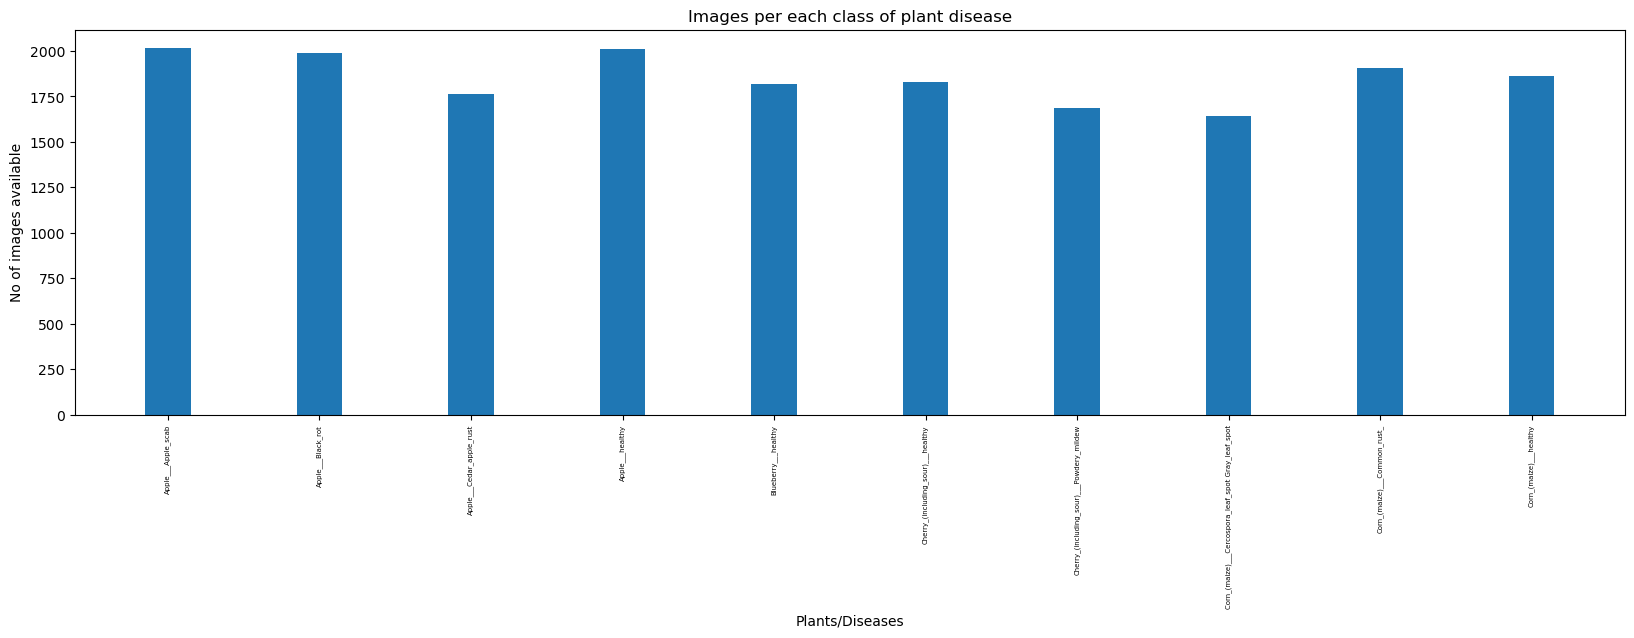

In [81]:
# plotting number of images available for each disease
index = [n for n in range(len(nums))]
plt.figure(figsize=(20, 5))
plt.bar(index, [n for n in nums.values()], width=0.3)
plt.xlabel('Plants/Diseases', fontsize=10)
plt.ylabel('No of images available', fontsize=10)
plt.xticks(index, diseases, fontsize=5, rotation=90)
plt.title('Images per each class of plant disease')

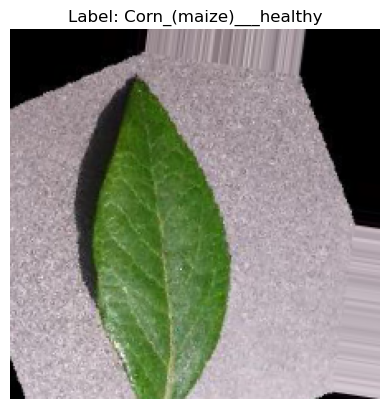

In [91]:
import matplotlib.pyplot as plt
import numpy as np

# Get one batch of images and labels from training data
images, labels = next(train_data)

# Get class names
class_names = list(train_data.class_indices.keys())

# Get label index of first image
label_index = np.argmax(labels[0])

# Show image with label
plt.imshow(images[4])
plt.title(f"Label: {class_names[label_index]}")
plt.axis("off")
plt.show()

In [11]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=25,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

In [13]:
valid_datagen = ImageDataGenerator(rescale=1./255)
test_datagen  = ImageDataGenerator(rescale=1./255)

In [31]:
train_data = train_datagen.flow_from_directory(
    train_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)
valid_data = valid_datagen.flow_from_directory(
    valid_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)
test_data = test_datagen.flow_from_directory(
    test_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode=None,   # 🔥 IMPORTANT
    shuffle=False
)

Found 18504 images belonging to 10 classes.
Found 4626 images belonging to 10 classes.
Found 33 images belonging to 8 classes.


In [33]:
print(train_data.num_classes)

10


In [19]:
model = tf.keras.models.Sequential([
    tf.keras.layers.Conv2D(32, (3,3), activation='relu', input_shape=(IMG_SIZE, IMG_SIZE, 3)),
    tf.keras.layers.MaxPooling2D(2,2),

    tf.keras.layers.Conv2D(64, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2,2),

    tf.keras.layers.Conv2D(128, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2,2),

    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(256, activation='relu'),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(train_data.num_classes, activation='softmax')
])

C:\Users\sai\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [21]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 222, 222, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 111, 111, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 109, 109, 64)        │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 54, 54, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 52, 52, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 26, 26, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 86528)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 256)                 │      22,151,424 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 10)                  │           2,570 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 22,247,242 (84.87 MB)

 Trainable params: 22,247,242 (84.87 MB)

 Non-trainable params: 0 (0.00 B)

In [23]:
history = model.fit(
    train_data,
    validation_data=valid_data,
    epochs=EPOCHS
)

Epoch 1/2
579/579 ━━━━━━━━━━━━━━━━━━━━ 1179s 2s/step - accuracy: 0.5224 - loss: 1.3379 - val_accuracy: 0.7890 - val_loss: 0.6012
Epoch 2/2
579/579 ━━━━━━━━━━━━━━━━━━━━ 938s 2s/step - accuracy: 0.8047 - loss: 0.5732 - val_accuracy: 0.9099 - val_loss: 0.2675


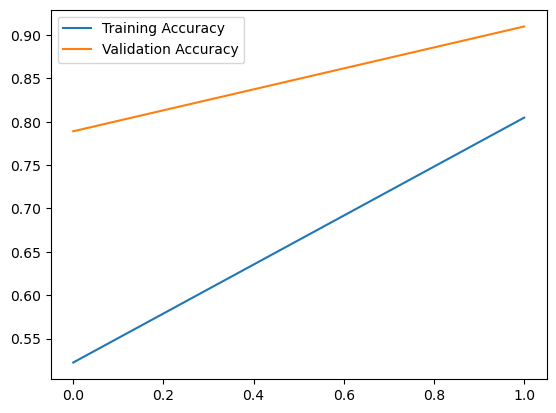

In [25]:
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.show()

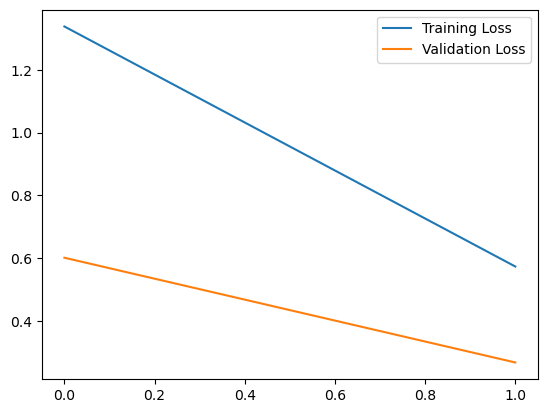

In [27]:
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.show()

In [35]:
predictions = model.predict(test_data)
predicted_classes = np.argmax(predictions, axis=1)

class_labels = list(train_data.class_indices.keys())

for i in range(10):
    print(f"Image {i} → Predicted class: {class_labels[predicted_classes[i]]}")

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 139ms/step
Image 0 → Predicted class: Apple___Cedar_apple_rust
Image 1 → Predicted class: Apple___Cedar_apple_rust
Image 2 → Predicted class: Apple___Cedar_apple_rust
Image 3 → Predicted class: Apple___Cedar_apple_rust
Image 4 → Predicted class: Cherry_(including_sour)___Powdery_mildew
Image 5 → Predicted class: Apple___Apple_scab
Image 6 → Predicted class: Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot
Image 7 → Predicted class: Corn_(maize)___Common_rust_
Image 8 → Predicted class: Corn_(maize)___Common_rust_
Image 9 → Predicted class: Corn_(maize)___Common_rust_


In [37]:
y_pred = model.predict(test_data)
y_pred_classes = np.argmax(y_pred, axis=1)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step 


In [39]:
from sklearn.metrics import classification_report, confusion_matrix

In [43]:
# Predict only
y_pred = model.predict(test_data)
y_pred_classes = np.argmax(y_pred, axis=1)

class_labels = list(train_data.class_indices.keys())

for i in range(10):
    print(f"Image {i} → Predicted class: {class_labels[y_pred_classes[i]]}")

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step 
Image 0 → Predicted class: Apple___Cedar_apple_rust
Image 1 → Predicted class: Apple___Cedar_apple_rust
Image 2 → Predicted class: Apple___Cedar_apple_rust
Image 3 → Predicted class: Apple___Cedar_apple_rust
Image 4 → Predicted class: Cherry_(including_sour)___Powdery_mildew
Image 5 → Predicted class: Apple___Apple_scab
Image 6 → Predicted class: Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot
Image 7 → Predicted class: Corn_(maize)___Common_rust_
Image 8 → Predicted class: Corn_(maize)___Common_rust_
Image 9 → Predicted class: Corn_(maize)___Common_rust_


In [45]:
conf_mat = confusion_matrix(test_data.classes, y_pred_classes)
print(conf_mat)

[[0 0 4 0 0 0 0 0 0]
 [1 0 0 0 0 1 0 1 0]
 [0 0 0 0 0 0 0 0 3]
 [2 0 1 1 0 0 0 1 0]
 [0 0 0 0 0 0 2 0 0]
 [0 1 1 4 0 0 0 0 0]
 [1 0 0 2 0 1 0 0 0]
 [0 0 0 0 0 6 0 0 0]
 [0 0 0 0 0 0 0 0 0]]


In [47]:
model.save("plant_disease_model.h5")

In [49]:
loaded_model = tf.keras.models.load_model("plant_disease_model.h5")

In [51]:
from tensorflow.keras.preprocessing import image

In [53]:
def predict_image(img_path):
    img = image.load_img(img_path, target_size=(IMG_SIZE, IMG_SIZE))
    img = image.img_to_array(img)
    img = img / 255.0
    img = np.expand_dims(img, axis=0)

    prediction = loaded_model.predict(img)
    class_idx = np.argmax(prediction)

    class_labels = list(train_data.class_indices.keys())
    return class_labels[class_idx]

In [63]:
predict_image(
r"C:\Users\sai\Downloads\Plant_Disease_Dataset (1)\New Plant Diseases Dataset(Augmented)\test\AppleCedarRust\AppleCedarRust1.JPG"
)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 230ms/step


'Apple___Cedar_apple_rust'

In [65]:
train_acc = history.history['accuracy'][-1]
val_acc   = history.history['val_accuracy'][-1]
print(f"Training Accuracy  : {train_acc * 100:.2f}%")
print(f"Validation Accuracy: {val_acc * 100:.2f}%")

Training Accuracy  : 80.47%
Validation Accuracy: 90.99%
